In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from scipy.stats.qmc import LatinHypercube
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import h3
from sklearn.base import clone
from itertools import product
import copy
from sklearn.metrics import f1_score
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from collections import ChainMap
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import branca.colormap as cm
import folium
import shap

In [72]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [73]:
def calculate_confusion_stats(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn
    
def micro_averaged_metrics(y_true, y_pred):
    tp, tn, fp, fn = calculate_confusion_stats(y_true, y_pred)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1, tp, tn, fp, fn
    
def calculate_auc_stats(y_true, y_proba):
    thresholds = np.linspace(0, 1, 101)
    tpr_list = []
    fpr_list = []
    
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        tp, tn, fp, fn = calculate_confusion_stats(y_true, y_pred)
        
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        
        tpr_list.append(tpr)
        fpr_list.append(fpr)
    return np.array(tpr_list), np.array(fpr_list)
    
def plot_roc_curve(fpr, tpr):
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

def get_report(y_true, y_pred, y_proba):
    precision, recall, f1, tp, tn, fp, fn = micro_averaged_metrics(y_true, y_pred)
    tpr, fpr = calculate_auc_stats(y_true, y_proba)
    print(f'TP = {tp}\t FP = {fp}')
    print(f'FN = {fn}\t TN = {tn}')
    print(f'precision = {precision}')
    print(f'recall = {recall}')
    print(f'f1 = {f1}')
    plot_roc_curve(fpr, tpr)

In [74]:
def get_hex_neighbors(h3_index):
    return h3.grid_disk(h3_index, k=1)[1:] 

In [75]:
def sample_lhs_from_grid(param_grid, n_samples, random_state=None):
    rng = np.random.RandomState(random_state)
    keys = list(param_grid.keys())
    grid_ranges = [param_grid[k] for k in keys]

    sampler = LatinHypercube(d=len(keys), seed=random_state)
    sample = sampler.random(n=n_samples)

    lhs_samples = []
    for row in sample:
        params = {}
        for i, val in enumerate(row):
            values = grid_ranges[i]
            idx = int(val * len(values))
            idx = min(idx, len(values) - 1)
            params[keys[i]] = [values[idx]]
        lhs_samples.append(params)

    return lhs_samples


In [76]:
def custom_balanced_folds(
    X,
    y,
    random_state=42
):
    rng = np.random.RandomState(random_state)

    idx_0 = y[y == 0].index.to_list()
    idx_1 = y[y == 1].index.to_list()

    rng.shuffle(idx_0)
    rng.shuffle(idx_1)

    train_min_per_class = int(len(idx_1) * 0.8)
    val_min_per_class = len(idx_1) - train_min_per_class

    n_folds = int(len(idx_0) // train_min_per_class)
    if int(len(idx_0) % train_min_per_class) == 1:
        n_folds += 1
        
    train_0_chunks = np.array_split(idx_0, n_folds)

    folds = []
    for i in range(n_folds):
        train_0 = train_0_chunks[i].tolist()
        val_0_pool = list(set(idx_0) - set(train_0))
        replace_0 = len(val_0_pool) < val_min_per_class
        val_0 = rng.choice(val_0_pool, size=val_min_per_class, replace=replace_0).tolist()

        val_1 = rng.choice(idx_1, size=val_min_per_class, replace=False).tolist()
        train_1_pool = list(set(idx_1) - set(val_1))
        replace_1 = len(train_1_pool) < train_min_per_class
        train_1 = rng.choice(train_1_pool, size=train_min_per_class, replace=replace_1).tolist()

        train_idx = train_1 + train_0
        val_idx = val_1 + val_0

        folds.append((train_idx, val_idx))

    return folds

In [77]:
def generate_epoch_datasets(
    X,
    y,
    h3_indices_train,
    n_epochs=6,
    base_random_state=RANDOM_STATE
):
    X = X.reset_index(drop=True).copy()
    y = y.reset_index(drop=True).copy()
    h3_indices_train = h3_indices_train.reset_index(drop=True).copy()
    
    datasets = []
    
    for epoch in range(n_epochs):
        epoch_seed = base_random_state + epoch
        
        selected_indices = []
        remaining_indices = set(range(len(X)))

        rng = np.random.RandomState(epoch_seed)
        
        while remaining_indices:
            idx = rng.choice(list(remaining_indices))
            selected_indices.append(idx)
            
            current_h3 = h3_indices_train.iloc[idx]
            neighbors = []
            for i in remaining_indices:
                if (h3_indices_train.iloc[i] in get_hex_neighbors(current_h3)) and (y.iloc[i] == 0):
                    neighbors.append(i)
                    
            remaining_indices -= {idx, *neighbors}
        
        X_epoch = X.iloc[selected_indices]
        y_epoch = y.iloc[selected_indices]
        h3_epoch = h3_indices_train.iloc[selected_indices]
        datasets.append((X_epoch, y_epoch, h3_epoch))
    
    return datasets
    
def train_model(
    model,
    X,
    y,
    generate_dataset=None,
    h3_indices_train=None,
    n_epochs=6,
    random_state=RANDOM_STATE
):
    if generate_dataset:
        best_score = -1
        best_model = None

        all_y_true_best = []
        all_y_pred_best = []
        all_y_proba_best = []
        validation_x = []
        validation_h3 = []
        
        datasets = generate_dataset(X, y, h3_indices_train, n_epochs, random_state)
        
        all_y_true = []
        all_y_pred = []
        all_y_proba = []
        
        for epoch, (X_epoch, y_epoch, h3_epoch) in enumerate(datasets):

            X_epoch = X_epoch.reset_index(drop=True)
            y_epoch = y_epoch.reset_index(drop=True)
            h3_epoch = h3_epoch.reset_index(drop=True)
            
            custom_cv = custom_balanced_folds(X_epoch, y_epoch, random_state=random_state)
            
            for train_idx, val_idx in custom_cv:
                X_tr, X_val = X_epoch.iloc[train_idx], X_epoch.iloc[val_idx]
                y_tr, y_val = y_epoch.iloc[train_idx], y_epoch.iloc[val_idx]
                h3_val = h3_epoch.iloc[val_idx]
                
                validation_x.append(X_val)
                validation_h3.append(h3_val)
                
                model.fit(X_tr, y_tr)
                
                y_pred = model.predict(X_val)
                y_proba = model.predict_proba(X_val)[:, 1]
                
                all_y_true.extend(y_val)
                all_y_pred.extend(y_pred)
                all_y_proba.extend(y_proba)
            
            precision, recall, f1, tp, tn, fp, fn = micro_averaged_metrics(np.array(all_y_true), np.array(all_y_pred))
            if f1 > best_score:
                best_score = f1
                best_model = copy.deepcopy(model)
                all_y_true_best = all_y_true.copy()
                all_y_pred_best = all_y_pred.copy()
                all_y_proba_best = all_y_proba.copy()
                print(f"Новый лучший результат! Сохраняем модель эпохи {epoch}")
                
            print(f"epoch:{epoch}, f1: {f1}")
        
        print('Результаты полученные на валидационной выборке')
        get_report(np.array(all_y_true_best), np.array(all_y_pred_best), np.array(all_y_proba_best))
        
        # Создаем DataFrame с исходными X и соответствующими вероятностями
        result_df = pd.concat(validation_x, axis=0)
        result_df['y_true'] = all_y_true
        result_df['y_proba'] = all_y_proba
        result_df['h3_index'] = pd.concat(validation_h3, axis=0)
    
        return result_df
        
    else:
        X_train, y_train = X, y
        
            
        all_y_true = []
        all_y_pred = []
        all_y_proba = []
        val_indices = []  # Будем сохранять индексы валидационных выборок

        X_train = X_train.reset_index(drop=True)
        y_train = y_train.reset_index(drop=True)

        custom_cv = custom_balanced_folds(X_train, y_train, random_state=random_state)

        for train_idx, val_idx in custom_cv:
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
                
            model.fit(X_tr, y_tr)
            
            y_pred = model.predict(X_val)
            y_proba = model.predict_proba(X_val)[:, 1]
            
            all_y_true.extend(y_val)
            all_y_pred.extend(y_pred)
            all_y_proba.extend(y_proba)
            val_indices.extend(val_idx)  # Сохраняем индексы
        
        print('Результаты полученные на валидационной выборке')
        get_report(np.array(all_y_true), np.array(all_y_pred), np.array(all_y_proba))
        
        # Создаем DataFrame с исходными X и соответствующими вероятностями
    result_df = X_train.iloc[val_indices].copy()
    result_df['y_true'] = all_y_true
    result_df['y_proba'] = all_y_proba
    result_df['h3_index'] = h3_indices_train.iloc[val_indices].copy()
    
    return result_df

In [78]:
# def train_model(
#     model,
#     X_full_train,
#     y_full_train,
#     generate_dataset=None,
#     h3_indices_train=None,
#     random_state=RANDOM_STATE
# ):
#     if generate_dataset:
#         X_train, y_train = generate_dataset(X_full_train, y_full_train, h3_indices_train, random_state)
        
#         X_train = X_train.reset_index(drop=True).copy()
#         y_train = y_train.reset_index(drop=True).copy()
#         h3_indices_train = h3_indices_train.reset_index(drop=True).copy()
#     else:
#         X_train, y_train = X_full_train, y_full_train
        
#         X_train = X_train.reset_index(drop=True).copy()
#         y_train = y_train.reset_index(drop=True).copy()

#     custom_cv = custom_balanced_folds(X_train, y_train, random_state=random_state)
        
#     all_y_true = []
#     all_y_pred = []
#     all_y_proba = []
#     val_indices = []  # Будем сохранять индексы валидационных выборок

#     for train_idx, val_idx in custom_cv:
#         X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
#         y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
#         model.fit(X_tr, y_tr)
        
#         y_pred = model.predict(X_val)
#         y_proba = model.predict_proba(X_val)[:, 1]
        
#         all_y_true.extend(y_val)
#         all_y_pred.extend(y_pred)
#         all_y_proba.extend(y_proba)
#         val_indices.extend(val_idx)  # Сохраняем индексы
    
#     print('Результаты полученные на валидационной выборке')
#     get_report(np.array(all_y_true), np.array(all_y_pred), np.array(all_y_proba))
    
#     # Создаем DataFrame с исходными X и соответствующими вероятностями
#     result_df = X_train.iloc[val_indices].copy()
#     result_df['y_true'] = all_y_true
#     result_df['y_proba'] = all_y_proba
#     result_df['h3_index'] = h3_indices_train.iloc[val_indices].copy()
    
#     return result_df

In [79]:
def evaluate_model(
    model,
    X_test,
    y_test,
    h3_indices_test
):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print('Результаты полученные на тестовой выборке')
    get_report(y_test, y_pred, y_proba)
    result_df = X_test.copy()
    result_df['y_true'] = y_pred
    result_df['y_proba'] = y_proba
    result_df['h3_index'] = h3_indices_test.copy()
    return result_df

In [80]:
df = pd.read_csv('/Users/dmitrystarukhin/final_diploma_mipt_sumgf/london/data/final_datasets/clean_reduced_dataset_london.csv')

relevant_columns = [
    'parking_area', 'traffic_count',
       'highway', 'public_transport', 'railway', 'subway', 'voltage',
       'bicycle_amenities', 'bike_amenities',
       'car_amenities', 'children_amenity', 'food_amenities', 'health_amenity',
       'home_amenities', 'infrastructure_amenities', 'other_amenities',
       'pet_amenity', 'social_amenities',
       'water_amenities', 'work_amenity',
       'leisure_amenities', 'needs_amenities', 'shops_amenities',
       'study_amenity', 'distance_to_center'

]

X = df[relevant_columns]
y = df['сharger_number'].apply(lambda x: 1 if x > 0 else 0)  # бинарная классификация
h3_indices = df['h3_index']

In [81]:
idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]

n_samples = min(int(0.3 * len(idx_0)), int(0.3 * len(idx_1)), int(0.5 * 0.3 * len(y)))

rng = np.random.RandomState(RANDOM_STATE)
test_idx_0 = rng.choice(idx_0, size=n_samples, replace=False)
test_idx_1 = rng.choice(idx_1, size=n_samples, replace=False)

test_idx = np.concatenate([test_idx_0, test_idx_1])
train_idx_full = np.setdiff1d(np.arange(len(y)), test_idx)

X_train_full, X_test = X.iloc[train_idx_full], X.iloc[test_idx]
y_train_full, y_test = y.iloc[train_idx_full], y.iloc[test_idx]
h3_indices_train_full, h3_indices_test = h3_indices.iloc[train_idx_full], h3_indices.iloc[test_idx]

X_train_full_0 = X_train_full[y_train_full == 0]
X_train_full_1 = X_train_full[y_train_full == 1]
y_train_full_0 = y_train_full[y_train_full == 0]
y_train_full_1 = y_train_full[y_train_full == 1]
h3_indices_train_full_0 = h3_indices_train_full[y_train_full == 0]
h3_indices_train_full_1 = h3_indices_train_full[y_train_full == 1]

mean_has_chargers = X_train_full_1.mean(axis=0)

similarities = cosine_similarity(
    X_train_full_0,
    mean_has_chargers.values.reshape(1, -1)
).flatten()
threshold = np.percentile(similarities, 75)

X_train_0_negative = X_train_full_0[similarities >= threshold] #похожие на места с зарядками (ложные нули)
X_train_0_positive = X_train_full_0[similarities < threshold] #непохожие на места с зарядками (реальные нули)
y_train_0_negative  = y_train_full_0[similarities >= threshold] 
y_train_0_positive = y_train_full_0[similarities < threshold]
h3_indices_train_0_negative  = h3_indices_train_full_0[similarities >= threshold] 
h3_indices_train_0_positive = h3_indices_train_full_0[similarities < threshold] 
print(f'ложные_нули.shape={X_train_0_negative.shape}, реальные_нули.shape={X_train_0_positive.shape}')
print()

X_train = pd.concat([X_train_0_positive, X_train_full_1])
y_train = pd.concat([y_train_0_positive, y_train_full_1])
h3_indices_train = pd.concat([h3_indices_train_0_positive, h3_indices_train_full_1])

X_full = X.copy()
y_full = y.copy()

print(f'X_train shape = {X_train.shape}, number 0 = {y_train[y_train == 0].shape}, number 1 = {y_train[y_train == 1].shape}')
print(f'X_test shape = {X_test.shape}, number 0 = {y_test[y_test == 0].shape}, number 1 = {y_test[y_test == 1].shape}')
print(f'X_full shape = {X_full.shape}, number 0 = {y_full[y_full == 0].shape}, number 1 = {y_full[y_full == 1].shape}')

ложные_нули.shape=(516, 25), реальные_нули.shape=(1548, 25)

X_train shape = (1776, 25), number 0 = (1548,), number 1 = (228,)
X_test shape = (194, 25), number 0 = (97,), number 1 = (97,)
X_full shape = (2486, 25), number 0 = (2161,), number 1 = (325,)


Новый лучший результат! Сохраняем модель эпохи 0
epoch:0, f1: 0.7724867724867726
epoch:1, f1: 0.7346938775510203
epoch:2, f1: 0.7383015597920277
epoch:3, f1: 0.7461139896373056
epoch:4, f1: 0.7499999999999999
epoch:5, f1: 0.7461139896373056
Результаты полученные на валидационной выборке
TP = 73	 FP = 24
FN = 19	 TN = 68
precision = 0.7525773195876289
recall = 0.7934782608695652
f1 = 0.7724867724867726


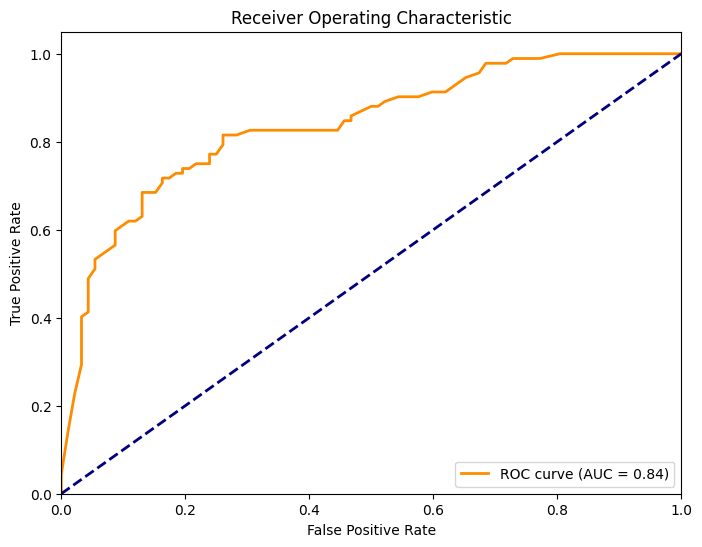

Результаты полученные на тестовой выборке
TP = 84	 FP = 36
FN = 13	 TN = 61
precision = 0.7
recall = 0.865979381443299
f1 = 0.7741935483870968


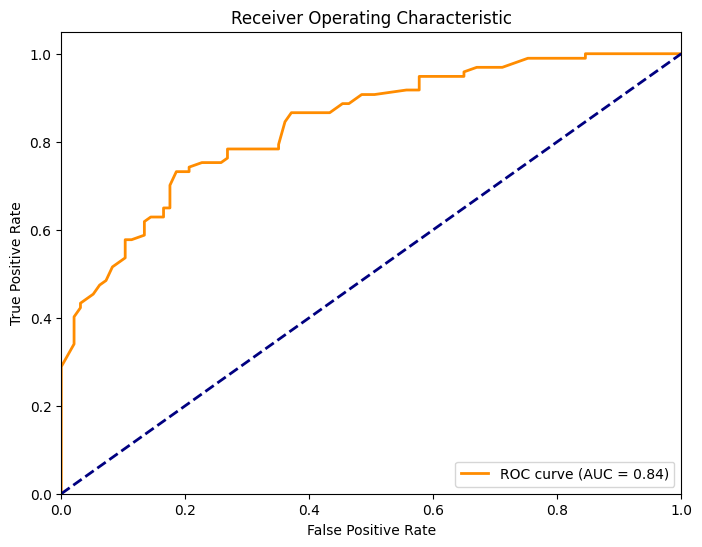

In [82]:
model = CatBoostClassifier(
    random_state=RANDOM_STATE,
    verbose=0,
    iterations=200,           
    depth=6,                  
    learning_rate=0.03,        
    l2_leaf_reg=1,             
    scale_pos_weight=3,        
    grow_policy='Depthwise',
    border_count=32            
)

result_train = train_model(
    model,
    X=X_train,
    y=y_train,
    generate_dataset=generate_epoch_datasets,
    h3_indices_train=h3_indices_train,
)

result_test = evaluate_model(
    model,
    X_test=X_test,
    y_test=y_test,
    h3_indices_test=h3_indices_test
)

In [83]:
def plot_confusion_matrix(
    TP,
    FP,
    FN,
    TN,
    process_name
):
    conf_matrix = [[TP, FP],
               [FN, TN]]
    
    print(f'{process_name}:')
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, 
                annot=True, 
                fmt='d', 
                cmap='Blues',
                xticklabels=['Верные(1)', 'Ложные(0)'],
                yticklabels=['Верные(1)', 'Ложные(0)'])
    plt.xlabel('Истинный класс')
    plt.ylabel('Прдесказанный класс')
    plt.show()
    
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    f1 = 2 * (precision * recall) / (precision + recall)
    
    print(f'Точность: {precision:.3f}')
    print(f'Полнота: {recall:.3f}')
    print(f'Правильность (Accuracy): {accuracy:.3f}')
    print(f'F1-метрика: {f1:.3f}')
    

Обучение:


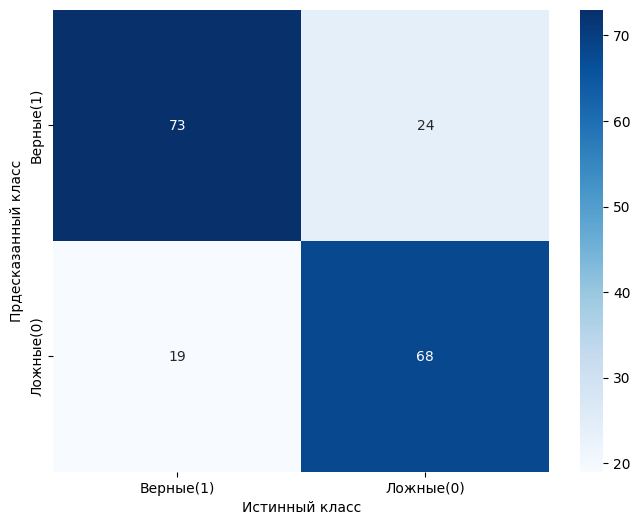

Точность: 0.753
Полнота: 0.793
Правильность (Accuracy): 0.766
F1-метрика: 0.772


In [84]:
plot_confusion_matrix(
    TP=73,
    FP=24,
    FN=19,
    TN=68,
    process_name='Обучение',
)


Тест:


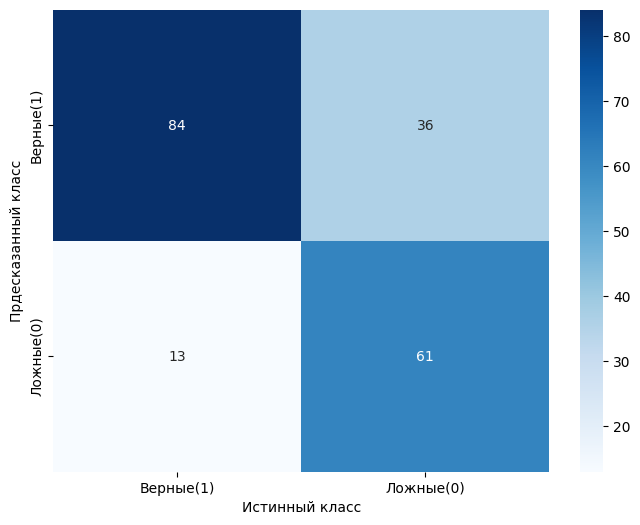

Точность: 0.700
Полнота: 0.866
Правильность (Accuracy): 0.747
F1-метрика: 0.774


In [85]:
plot_confusion_matrix(
    TP=84,
    FP=36,
    FN=13,
    TN=61,
    process_name='Тест'
)

In [86]:
result_train['dataset_type'] = 'train'
result_test['dataset_type'] = 'test'

combined_results = pd.concat([result_train, result_test], axis=0).reset_index(drop=True)

In [87]:
colormap = cm.LinearColormap(
    ['red', 'yellow', 'green'],
    vmin=0, vmax=1,
    caption='Вероятность установки (y_proba)'
)

avg_location = [51.505, -0.11]
m = folium.Map(location=avg_location, zoom_start=12)

existing_chargers = folium.FeatureGroup(name="Существующие зарядки")

for _, row in combined_results.iterrows():
    if pd.notna(row['h3_index']):
        hexagon = row['h3_index']
        proba = row['y_proba']
        
        hex_boundary = h3.cell_to_boundary(hexagon)
        color = colormap(proba)
        
        folium.Polygon(
            locations=hex_boundary,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            popup=f"""
                Вероятность: {proba:.2f}<br>
                Тип: {row['dataset_type']}<br>
                H3 индекс: {hexagon}
            """
        ).add_to(m)
        
        if row['y_true'] == 1:
            center = h3.cell_to_latlng(hexagon)
            folium.Marker(
                location=center,
                icon=folium.Icon(color='blue', icon='bolt', prefix='fa'),
                popup=f"Зарядная станция (H3: {hexagon})"
            ).add_to(existing_chargers)

existing_chargers.add_to(m)

folium.GeoJson(
    {
        "type": "FeatureCollection",
        "features": [
            {
                "type": "Feature",
                "properties": {},
                "geometry": {
                    "type": "Polygon",
                    "coordinates": [h3.cell_to_boundary(hex)]
                }
            } for hex in combined_results['h3_index']
        ]
    },
    name="Границы гексагонов",
    style_function=lambda x: {'color': 'black', 'fill': False}
).add_to(m)

colormap.add_to(m)
folium.LayerControl().add_to(m)

m.save('charging_stations_map.html')
m

In [88]:
columns_ru = {
    'bicycle_amenities': 'велоинфраструктура',
    'bike_amenities': 'мотоинфраструктура',
    'children_amenity': 'детская_инфраструктура',
    'food_amenities': 'питание',
    'health_amenity': 'медицина',
    'home_amenities': 'бытовая_инфраструктура',
    'infrastructure_amenities': 'городская_инфраструктура',
    'leisure_amenities': 'досуг',
    'other_amenities': 'прочая_инфраструктура',
    'pet_amenity': 'инфраструктура_для_животных',
    'social_amenities': 'социальная_инфраструктура',
    'water_amenities': 'водная_инфраструктура',
    'parking_area': 'парковки',
    'traffic_count': 'интенсивность_движения',
    'сharger_number': 'количество_зарядок', 
    'highway': 'шоссе',
    'public_transport': 'общественный_транспорт',
    'railway': 'железная_дорога',
    'subway': 'метро',
    'voltage': 'напряжение',
    'distance_class': 'класс_удаленности',
    'car_amenities': 'автоинфраструктура',
    'needs_amenities': 'повседневные_услуги',
    'shops_amenities': 'торговая_инфраструктура',
    'work_amenity': 'рабочая_инфраструктура',
    'has_charging_station': 'наличие_зарядки',
    'usage_type': 'тип_использования',
    'study_amenity': 'образовательная_инфраструктура',
    'latitude': 'широта',
    'longitude': 'долгота',
    'distance_to_center': 'расстояние_до_центра'
}

df = df.rename(columns=columns_ru)

/var/folders/vm/qhg8b4qj2296jrpn875q21fm0000gn/T/ipykernel_7672/4098237462.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


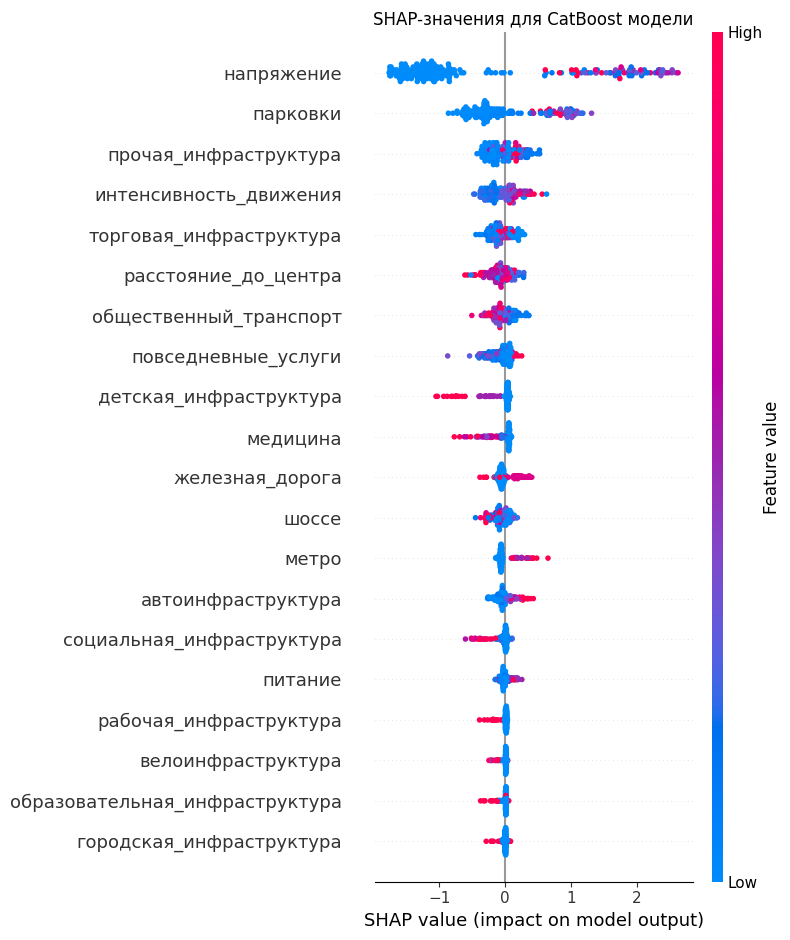

In [91]:
new_cols = {key: columns_ru[key] for key in X_test.columns}
X_test_ru = X_test.rename(columns=new_cols)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test,  
    feature_names=list(X_test_ru.columns),  
    show=False
)
plt.title("SHAP-значения для CatBoost модели")
plt.tight_layout()
plt.show()

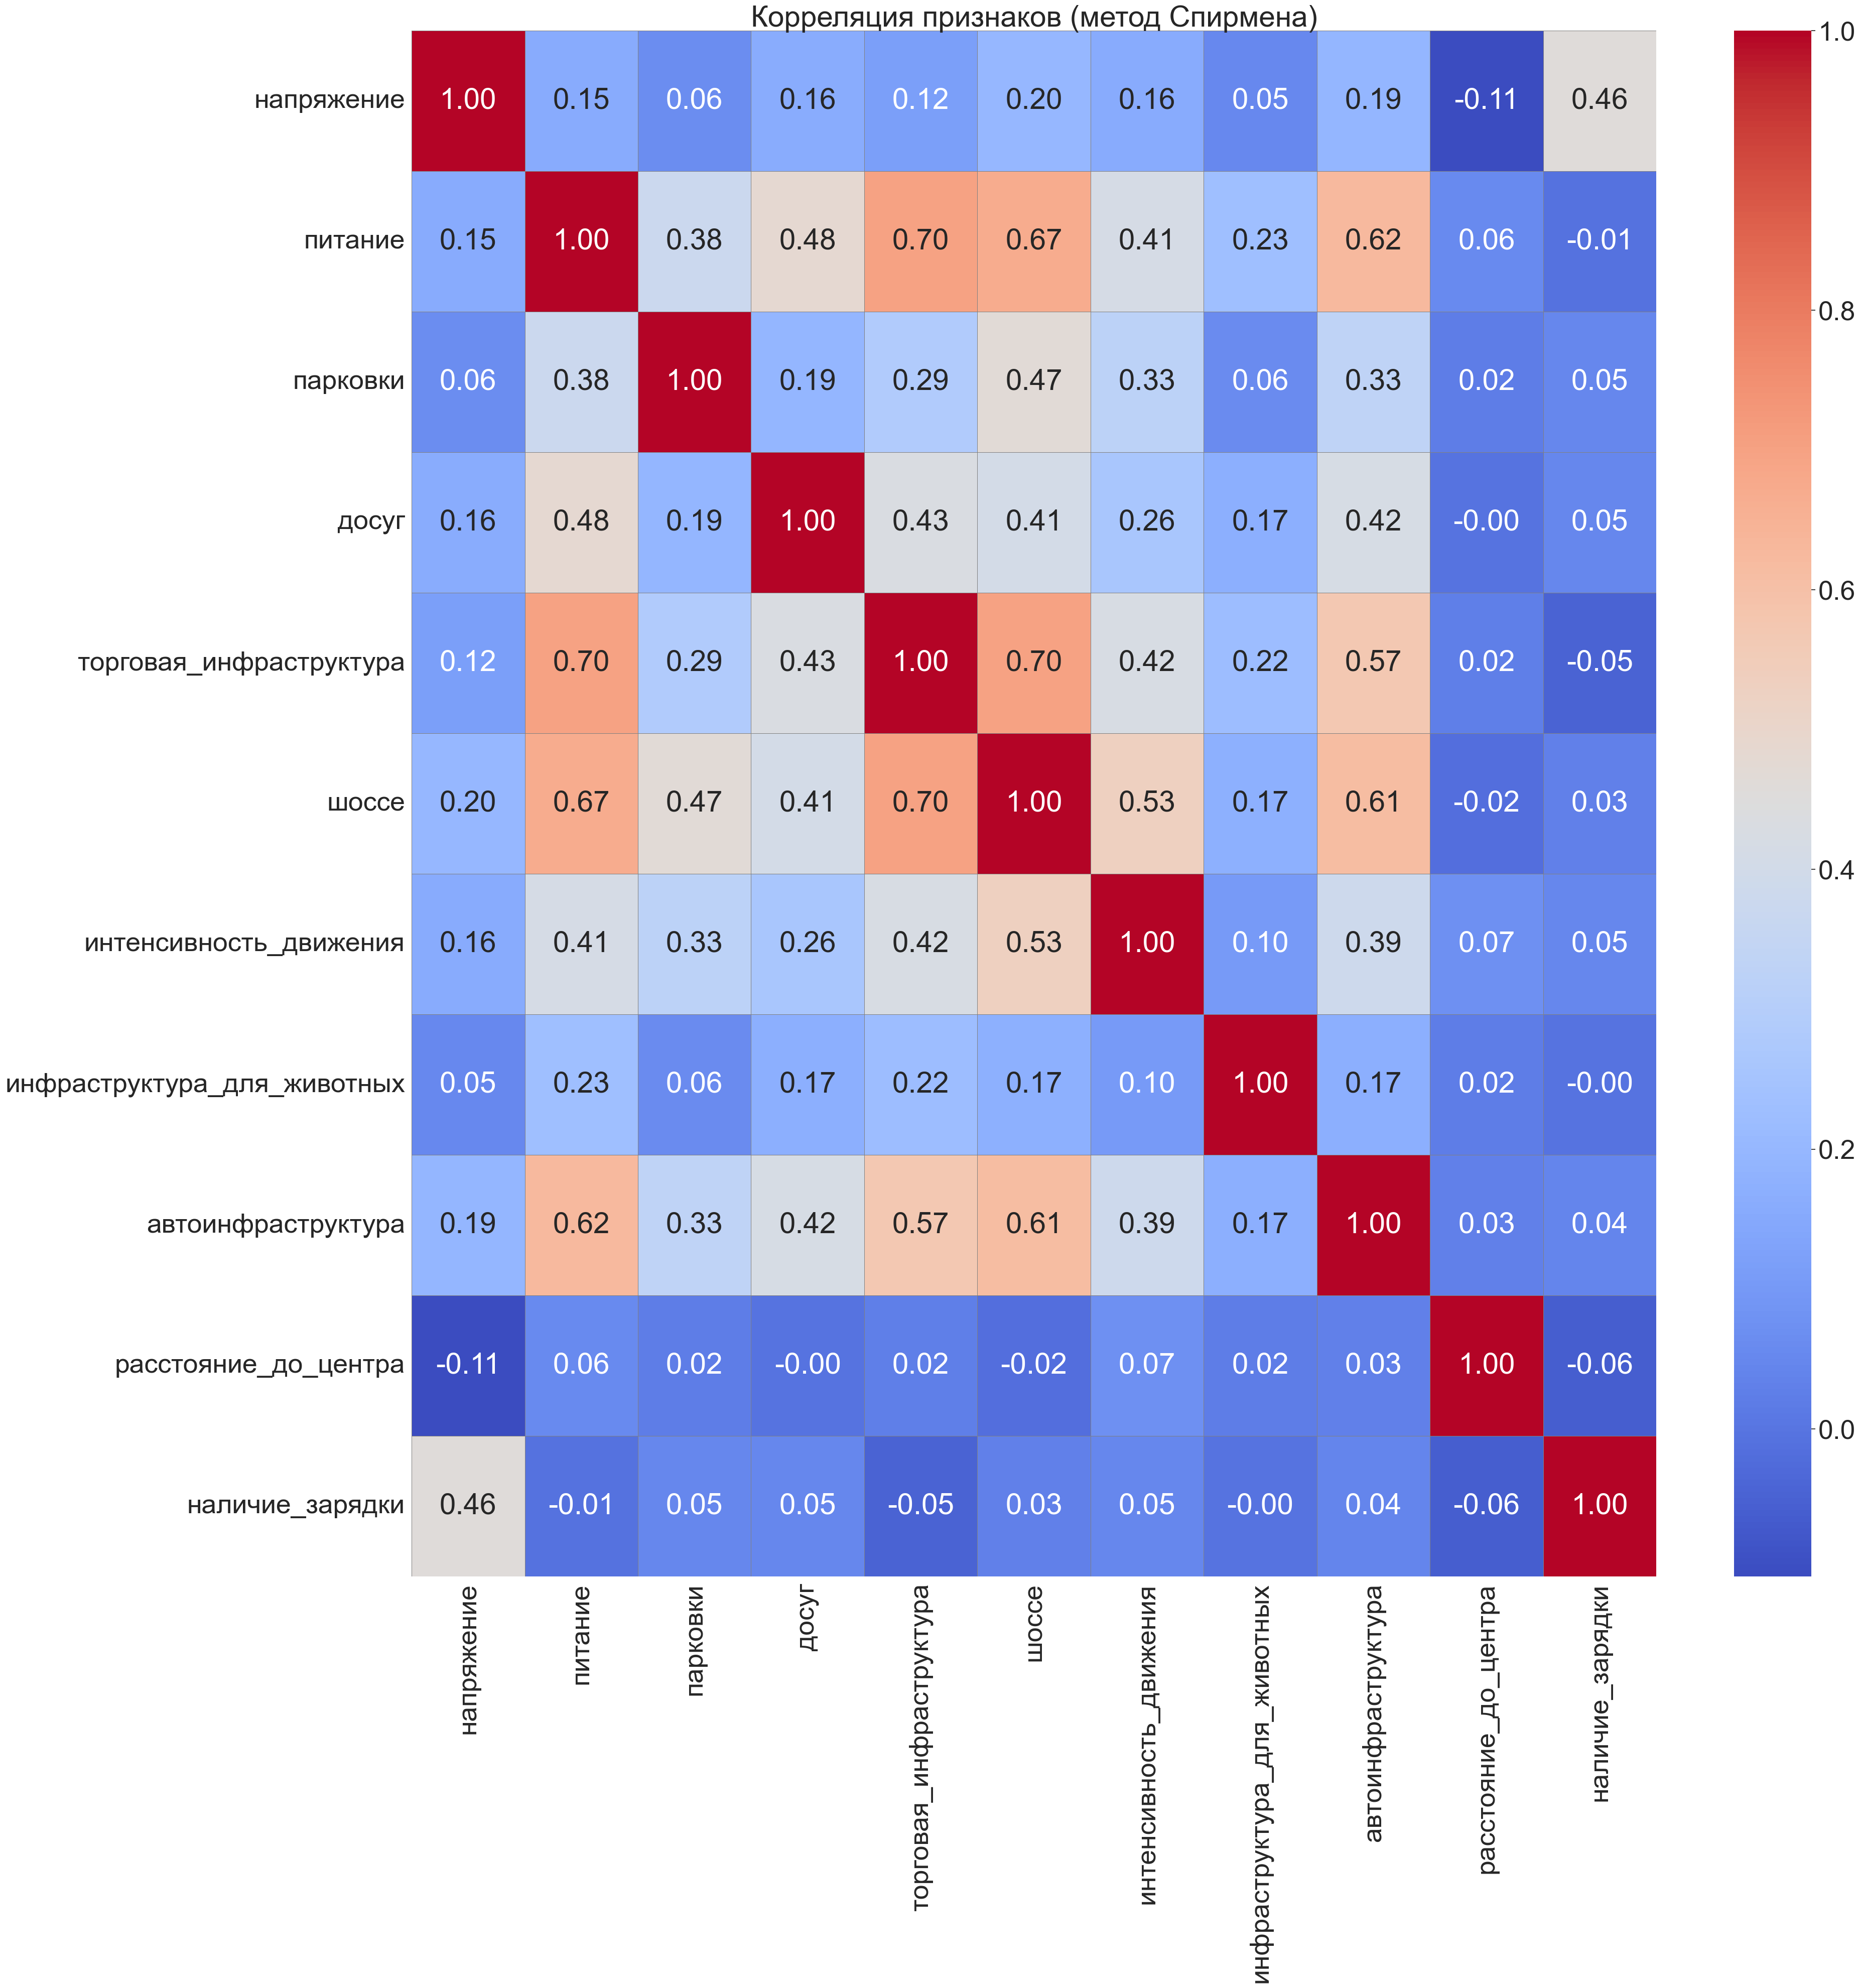

In [93]:
columns_to_plot_eng = ['voltage', 'food_amenities', 'parking_area', 'leisure_amenities', 'shops_amenities', 'highway',
                   'traffic_count', 'pet_amenity', 'car_amenities', 'distance_to_center', 'has_charging_station']
columns_to_plot = [columns_ru[key] for key in columns_to_plot_eng]
corr_matrix = df[columns_to_plot].corr(method='spearman', numeric_only=True)
sns.set(font_scale=3.5) 
plt.figure(figsize=(40, 40))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, linecolor='gray')


plt.title("Корреляция признаков (метод Спирмена)")
plt.show()